## Step 0: Install and Import Libraries

In [4]:
!pip install -q transformers datasets scikit-learn pandas openpyxl torch accelerate

In [3]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## Step 1: Load and Inspect the data

In [5]:
df = pd.read_excel("text_dataset/merged_text_dataset.xlsx")

print("Shape of the dataset:", df.shape)
print(df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nCategory distribution:\n", df["category"].value_counts())
print("\nUrgency level distribution:\n", df["urgency_level"].value_counts())

Shape of the dataset: (4344, 5)
                                         description        category  \
0  "घरायसी फोहोर ओभरफ्लो भएर व्यापारिक क्षेत्र को...  domestic_trash   
1  "Community drain partly blocked by leaves sinc...        drainage   
2  "Public bin overflowing onto the pavement, nea...           trash   
3  "Industrial drain filled with mud after rain a...        drainage   
4  "Cracked pavement creating a trip hazard at th...  infrastructure   

   urgency_score urgency_level location_type  
0            5.7        medium    commercial  
1            4.5        medium        public  
2            7.0          high       highway  
3            8.0          high        market  
4            3.5           low       highway  

Missing values:
 description      0
category         0
urgency_score    0
urgency_level    0
location_type    0
dtype: int64

Duplicate rows: 2

Category distribution:
 category
drainage             550
illegal_parking      548
road_damaged_sign    548

## Step 2: Clean and Preprocess the Data

In [6]:
def clean_text(text):
    text = str(text).strip()
    text = text.strip('"').strip("'")
    text = " ".join(text.split())
    return text

df["description"] = df["description"].apply(clean_text)

before = len(df)
df = df.drop_duplicates(subset=["description"]).reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows. Remaining: {len(df)}")

df["description"].sample(5, random_state=SEED).tolist()

Dropped 2 duplicate rows. Remaining: 4342


['The public bin is full and people are putting bags beside it. The smell is starting to bother people nearby.',
 'Road divider defaced with large drawings on a highway, sharp parts are exposed beside pedestrians.',
 'School boundary wall covered with spray-painted tags near an industrial road, damage is visible from the school gate.',
 'गाडीहरू अस्पताल को दुबै साइडमा गैरकानूनी पार्किङ गरेका छन्। चाँडै कारबाही लिनुपर्यो।',
 'There is a hole near the edge of the road where motorcycles pass. Vehicles are swerving to avoid the hole.']

## Step 3: Encode Labels

In [7]:
label_encoder = LabelEncoder()
df["category_label"] = label_encoder.fit_transform(df["category"])

num_labels = df["category_label"].nunique()
id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}

print("Number of categories:", num_labels)
print("Label mapping:", id2label)

#Optional: same idea for urgency_label if we train a seperate urgency classifier
urgency_encoder = LabelEncoder()
df["urgency_label"] = urgency_encoder.fit_transform(df["urgency_level"])
urgency_id2label = {i: label for i, label in enumerate(urgency_encoder.classes_)}
print("Urgency label mapping:", urgency_id2label)

Number of categories: 9
Label mapping: {0: 'domestic_trash', 1: 'drainage', 2: 'garbage', 3: 'illegal_parking', 4: 'infrastructure', 5: 'pothole', 6: 'road_damaged_sign', 7: 'trash', 8: 'vandalism'}
Urgency label mapping: {0: 'critical', 1: 'high', 2: 'low', 3: 'medium'}


## Exploratory Data Analysis

1. Category distribution — reveals class imbalance, which justifies using stratified splitting and macro-F1 instead of plain accuracy

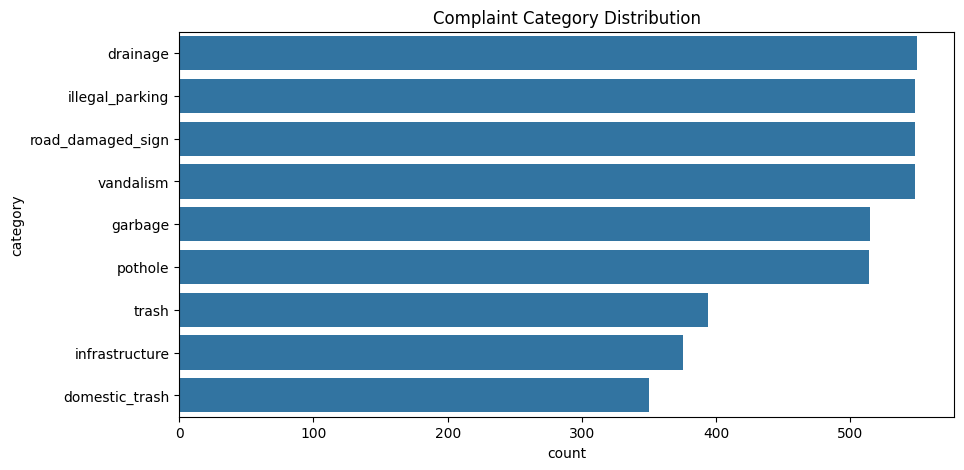

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.countplot(y=df["category"], order=df["category"].value_counts().index)
plt.title("Complaint Category Distribution")
plt.show()

2. Urgency level distribution

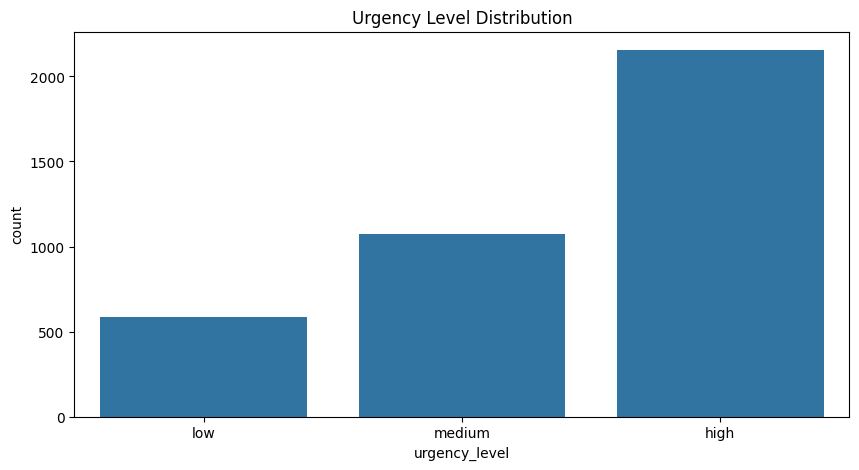

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df["urgency_level"], order=["low","medium","high"])
plt.title("Urgency Level Distribution")
plt.show()

3. Urgency score distribution (continuous) - shows the spread/shape, useful if you also do urgency as a regression task

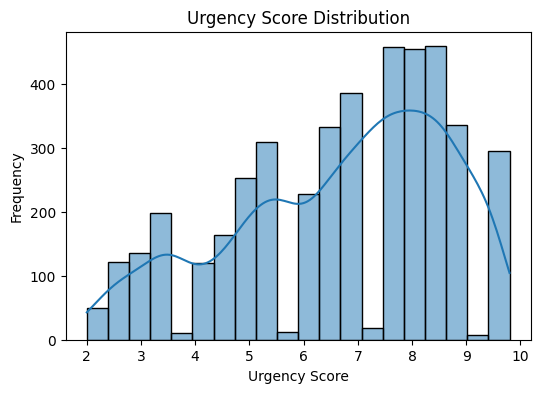

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["urgency_score"], bins=20, kde=True)
plt.title("Urgency Score Distribution")
plt.xlabel("Urgency Score")
plt.ylabel("Frequency")
plt.show()

4. Text length distribution - informs MAX_LENGTH tokenizer decision

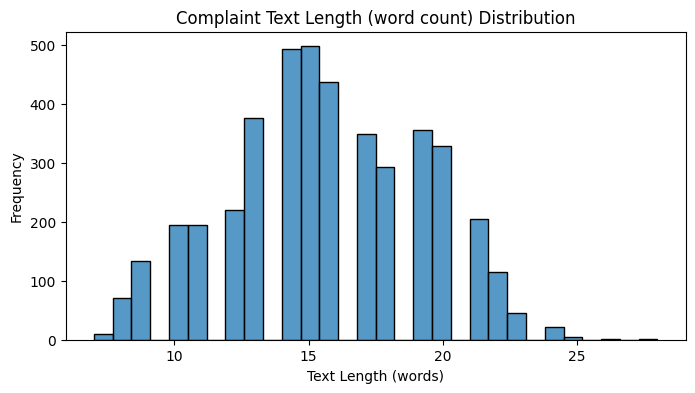

count    4342.000000
mean       15.623445
std         3.591607
min         7.000000
25%        13.000000
50%        15.000000
75%        18.000000
max        28.000000
Name: text_length, dtype: float64


In [11]:
df["text_length"] = df["description"].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,4))
sns.histplot(df["text_length"], bins=30)
plt.title("Complaint Text Length (word count) Distribution")
plt.xlabel("Text Length (words)")
plt.ylabel("Frequency")
plt.show()
print(df["text_length"].describe())

5. Category vs location_type — a useful cross-tab if location_type is a feature you plan to use downstream (e.g. for routing)

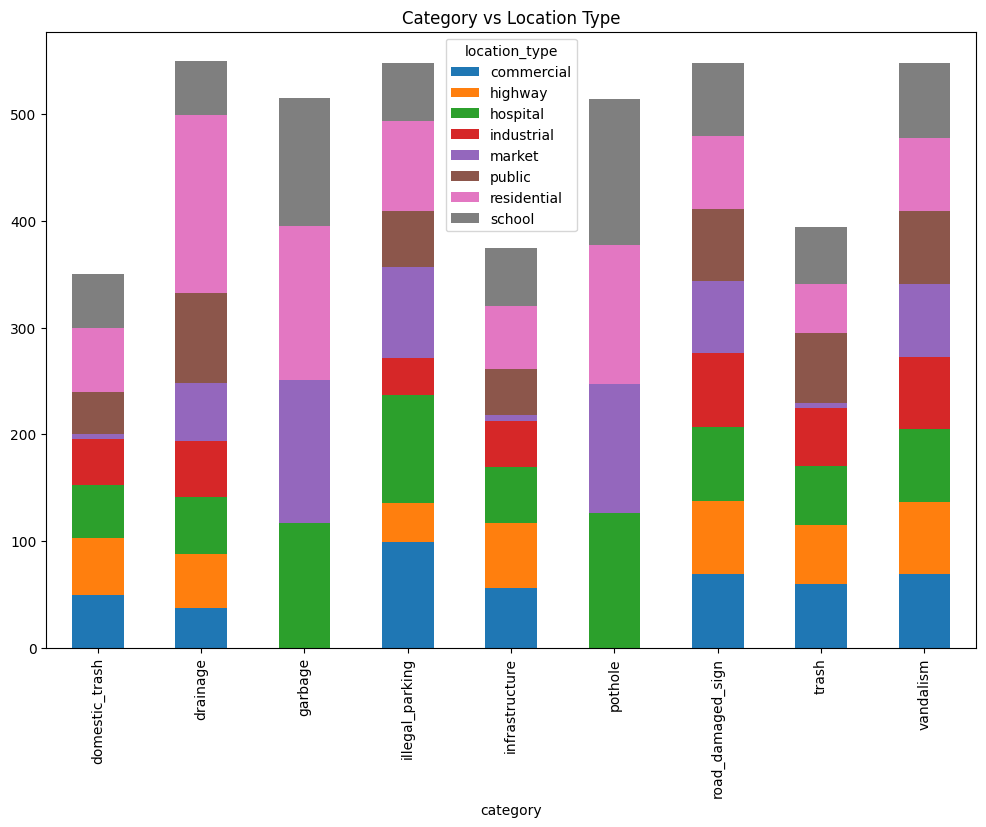

In [12]:
pd.crosstab(df["category"], df["location_type"]).plot(kind="bar", stacked=True, figsize=(12,8))
plt.title("Category vs Location Type")
plt.show()

6. Category vs urgency — see whether certain categories skew high/low urgency

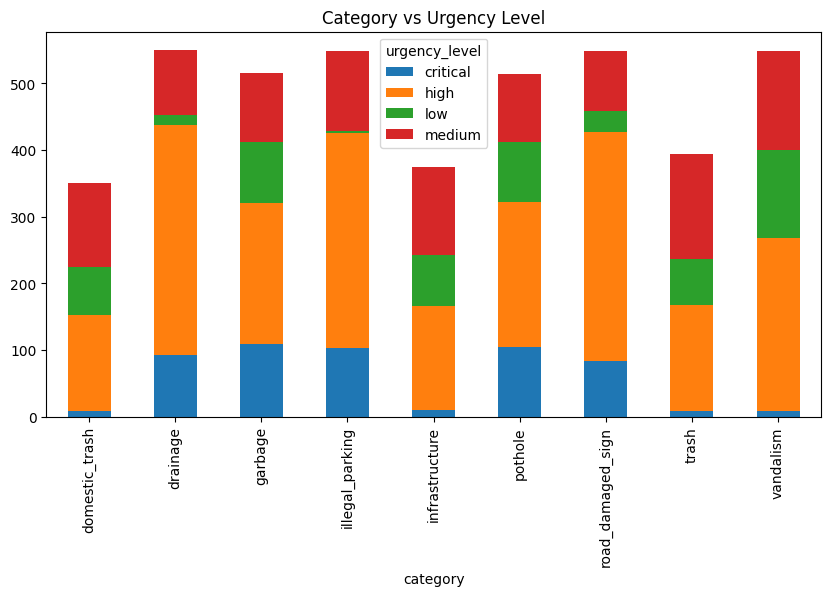

In [13]:
pd.crosstab(df["category"], df["urgency_level"]).plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Category vs Urgency Level")
plt.show()

## Step 4: Split into train, validation, and tests sets

In [14]:
train_val_df, test_df = train_test_split(
    df, test_size=0.15, 
    stratify=df["category_label"], 
    random_state=SEED
)

train_df, val_df = train_test_split(
    train_val_df, test_size=0.1765,
    stratify=train_val_df["category_label"], random_state=SEED
)

print ("Train:", len(train_df), "Validation:", len(val_df), "Test:", len(test_df))
train_df.to_csv("text_dataset/train.csv", index=False)
val_df.to_csv("text_dataset/validation.csv", index=False)
test_df.to_csv("text_dataset/test.csv", index=False)

Train: 3038 Validation: 652 Test: 652


## Step 5: Tokenize with the MuRIL tokenizer

In [15]:
MODEL_NAME = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

lengths = df["description"].apply(lambda t: len(tokenizer.tokenize(t)))
print("95th percentile token length:", int(np.percentile(lengths, 95)))
print("Max token length:", lengths.max())

MAX_LENGTH = 128 #adjust based on the printed percentile above
def tokenize_batch(examples):
    return tokenizer(
        examples["description"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
    )

95th percentile token length: 25
Max token length: 33


In [16]:
train_ds = Dataset.from_pandas(train_df[["description", "category_label"]].rename(columns={"category_label": "label"}))
val_ds = Dataset.from_pandas(val_df[["description", "category_label"]].rename(columns={"category_label": "label"}))
test_ds = Dataset.from_pandas(test_df[["description", "category_label"]].rename(columns={"category_label": "label"}))

train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds = val_ds.map(tokenize_batch, batched=True)
test_ds = test_ds.map(tokenize_batch, batched=True)

columns = ["input_ids", "attention_mask", "label"]
train_ds.set_format(type="torch", columns=columns)
val_ds.set_format(type="torch", columns=columns)
test_ds.set_format(type="torch", columns=columns)

Map:   0%|          | 0/3038 [00:00<?, ? examples/s]

Map:   0%|          | 0/652 [00:00<?, ? examples/s]

Map:   0%|          | 0/652 [00:00<?, ? examples/s]

## Step 6: Load and Configure the MuRIL Model

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params w

## Step 7: Define evaluation metrics

In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis = -1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

## Step 8: Train with validation monitoring

In [21]:
import transformers
print(transformers.__version__)

5.16.1


In [22]:
training_args = TrainingArguments(
    output_dir="./muril_Complaint_classifier",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

c:\Users\DELL\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.045436,1.903713,0.907975,0.829296,0.876763,0.844068
2,1.664810,1.550595,0.918712,0.836310,0.888889,0.854451
3,1.366869,1.290834,0.917178,0.835792,0.887446,0.853279
4,1.188304,1.141068,0.963190,0.967871,0.950339,0.949705
5,1.131833,1.092307,0.996933,0.996052,0.996461,0.996244


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\DELL\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

c:\Users\DELL\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\DELL\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=950, training_loss=1.5296457752428556, metrics={'train_runtime': 36130.0075, 'train_samples_per_second': 0.42, 'train_steps_per_second': 0.026, 'total_flos': 999227030376960.0, 'train_loss': 1.5296457752428556, 'epoch': 5.0})

## a. Extract logged metrics after training

In [23]:
import pandas as pd

# trainer.state.log_history contains every logged entry during training
log_history = trainer.state.log_history

# Separate training loss logs from evaluation logs
train_logs = [log for log in log_history if "loss" in log and "eval_loss" not in log]
eval_logs  = [log for log in log_history if "eval_loss" in log]

train_df_log = pd.DataFrame(train_logs)
eval_df_log  = pd.DataFrame(eval_logs)

print(train_df_log[["epoch", "loss"]])
print(eval_df_log[["epoch", "eval_loss", "eval_accuracy", "eval_f1"]])

       epoch      loss
0   0.263158  2.188715
1   0.526316  2.127065
2   0.789474  2.045436
3   1.052632  1.948608
4   1.315789  1.863329
5   1.578947  1.765573
6   1.842105  1.664810
7   2.105263  1.585999
8   2.368421  1.505504
9   2.631579  1.439539
10  2.894737  1.366869
11  3.157895  1.314899
12  3.421053  1.260527
13  3.684211  1.234642
14  3.947368  1.188304
15  4.210526  1.154859
16  4.473684  1.141420
17  4.736842  1.135337
18  5.000000  1.131833
   epoch  eval_loss  eval_accuracy   eval_f1
0    1.0   1.903713       0.907975  0.844068
1    2.0   1.550595       0.918712  0.854451
2    3.0   1.290834       0.917178  0.853279
3    4.0   1.141068       0.963190  0.949705
4    5.0   1.092307       0.996933  0.996244


## b. Plot training loss vs validation loss

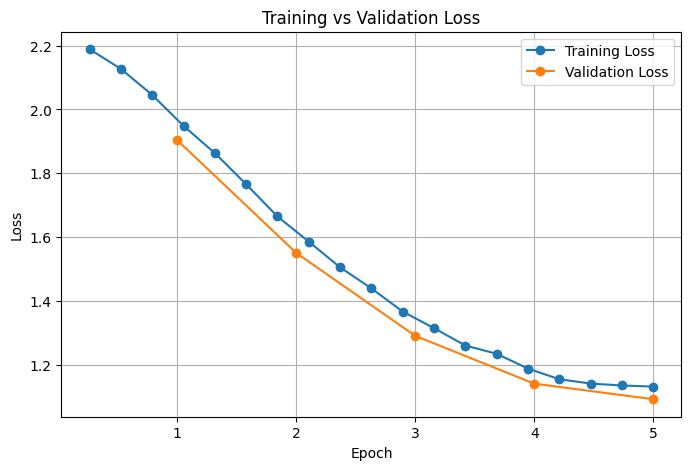

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_df_log["epoch"], train_df_log["loss"], label="Training Loss", marker="o")
plt.plot(eval_df_log["epoch"], eval_df_log["eval_loss"], label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## c. Plot validation accuracy and F1 accross epochs

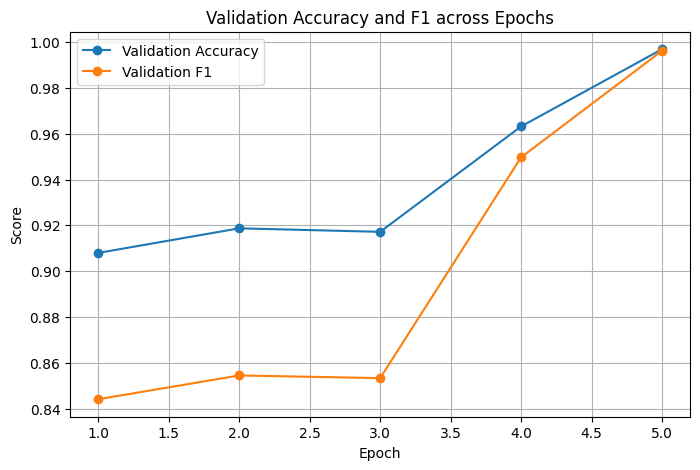

In [25]:
plt.figure(figsize=(8,5))
plt.plot(eval_df_log["epoch"], eval_df_log["eval_accuracy"], label="Validation Accuracy", marker="o")
plt.plot(eval_df_log["epoch"], eval_df_log["eval_f1"], label="Validation F1", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Accuracy and F1 across Epochs")
plt.legend()
plt.grid(True)
plt.show()

## Step 9: Evaluate on the help-out test set

In [26]:
test_results = trainer.evaluate(test_ds)
print("Test set results:", test_results)

preds_output = trainer.predict(test_ds)
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=-1)

print(classification_report(
    y_true, y_pred,
    target_names=[id2label[i] for i in range(num_labels)]
))

c:\Users\DELL\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
1.131833,1.090852,5,0.992331,0.991319,0.989518,0.989983


Test set results: {'eval_loss': 1.0908520221710205, 'eval_accuracy': 0.9923312883435583, 'eval_precision': 0.9913194444444444, 'eval_recall': 0.9895178197064989, 'eval_f1': 0.9899827381112095}


c:\Users\DELL\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


                   precision    recall  f1-score   support

   domestic_trash       1.00      0.91      0.95        53
         drainage       1.00      1.00      1.00        83
          garbage       1.00      1.00      1.00        78
  illegal_parking       1.00      1.00      1.00        82
   infrastructure       1.00      1.00      1.00        56
          pothole       1.00      1.00      1.00        77
road_damaged_sign       1.00      1.00      1.00        82
            trash       0.92      1.00      0.96        59
        vandalism       1.00      1.00      1.00        82

         accuracy                           0.99       652
        macro avg       0.99      0.99      0.99       652
     weighted avg       0.99      0.99      0.99       652



## Step 10: Save the fine-tuned model

In [27]:
trainer.save_model("./muril_complaint_classifier_final")
tokenizer.save_pretrained("./muril_complaint_classifier_final")
print("Model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved.
